# 1. Introduction and research question

This notebook studies whether oil price increases have different effects on financial markets depending on the macroeconomic environment behind the oil move.

The central idea is deliberately simple and transparent. We first build a clean monthly dataset from Bloomberg-style daily and monthly series. We then decompose monthly oil returns into a demand-related part and a residual non-demand-related part, and we test whether this distinction helps predict next-month equity returns and changes in high-yield credit spreads.

Throughout the notebook, the empirical strategy remains reduced-form. The fitted part of the oil return is interpreted as a demand-related oil movement, not as a fully identified structural demand shock. The residual is interpreted as a supply-related or non-demand-related movement, not as a perfectly identified structural supply shock.

# 2. Imports and setup

We keep the environment simple and use only standard libraries that are easy to explain orally: `pandas`, `numpy`, `matplotlib`, `statsmodels`, and `scipy`.

The helper functions are stored in a separate Python file so that the notebook stays readable, but the core empirical logic still appears step by step in the notebook.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from statsmodels.tsa.api import VAR

SRC_PATH = Path("../src")
if not SRC_PATH.exists():
    SRC_PATH = Path("src")
if str(SRC_PATH.resolve()) not in sys.path:
    sys.path.insert(0, str(SRC_PATH.resolve()))

from project_main import (
    DAILY_COLUMNS,
    MONTHLY_COLUMNS,
    add_regime_variables,
    aggregate_daily_to_monthly,
    build_project_variables,
    decompose_oil_returns,
    fit_predictive_regression,
    granger_pvalue_table,
    interpret_two_component_model,
    load_data_sheet,
    make_summary_statistics,
    normality_check,
    regression_results_table,
    rolling_forecast_comparison,
    run_adf_table,
    show_missing_report,
    split_sample,
)

warnings.filterwarnings("ignore")
plt.style.use("default")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.4f}".format)

DATA_PATH = Path("../data/raw/data_hec_projet_1.xlsx")
if not DATA_PATH.exists():
    DATA_PATH = Path("data/raw/data_hec_projet_1.xlsx")

print("Excel file found:", DATA_PATH.exists())
print("Excel path:", DATA_PATH.resolve())

Excel file found: True
Excel path: C:\Users\loren\EMF---Forecasting-the-Effect-of-Oil-Price-Increases-on-Financial-Markets\data\raw\data_hec_projet_1.xlsx


# 3. Data loading

We start by loading the raw daily and monthly sheets and cleaning the Bloomberg header rows. At this stage we do not transform the data yet. The goal is simply to verify that the dates, variable names, and sample ranges are coherent.

In [2]:
daily_raw = load_data_sheet(DATA_PATH, "Daily", DAILY_COLUMNS)
monthly_raw = load_data_sheet(DATA_PATH, "Monthly", MONTHLY_COLUMNS)

print("Daily raw shape:", daily_raw.shape)
print("Monthly raw shape:", monthly_raw.shape)
print("Daily date range:", daily_raw["date"].min(), "to", daily_raw["date"].max())
print("Monthly date range:", monthly_raw["date"].min(), "to", monthly_raw["date"].max())

print("\nCheck that the raw datasets are sorted and have unique monthly dates where expected:")
checks = {
    "Daily dates are sorted": daily_raw["date"].is_monotonic_increasing,
    "Monthly dates are sorted": monthly_raw["date"].is_monotonic_increasing,
    "Monthly dates are unique": monthly_raw["date"].is_unique,
}
for label, value in checks.items():
    print(f"{label}: {value}")

print("\nTable 1. First rows of the cleaned daily dataset")
display(daily_raw.head())

print("Table 2. First rows of the cleaned monthly macro dataset")
display(monthly_raw.head())

Daily raw shape: (9443, 14)
Monthly raw shape: (435, 9)
Daily date range: 1990-01-01 00:00:00 to 2026-03-11 00:00:00
Monthly date range: 1989-12-31 00:00:00 to 2026-02-28 00:00:00

Check that the raw datasets are sorted and have unique monthly dates where expected:
Daily dates are sorted: True
Monthly dates are sorted: True
Monthly dates are unique: True

Table 1. First rows of the cleaned daily dataset


,date,wti,brent,bcom_energy,tft,natgas,sp500,msci_world,msci_em,russell2000,us10y,us2y,hy_ytw,gold
0,1990-01-01,21.8200,19.6900,77.8405,NaN,NaN,353.4000,567.3400,214.6900,168.2280,7.9350,7.8410,16.0800,401.2500
1,1990-01-02,22.8900,19.9000,81.0621,NaN,NaN,359.6900,568.9600,217.3000,169.9430,7.9300,7.8750,16.0800,399.0000
2,1990-01-03,23.6800,20.9500,83.0504,NaN,NaN,358.7600,569.1000,220.4500,170.7800,7.9740,7.9270,16.0800,395.0000
3,1990-01-04,23.4100,20.7800,81.1315,NaN,NaN,355.6700,571.0200,227.3000,170.1680,7.9720,7.9100,16.0800,396.5000
4,1990-01-05,23.0800,20.7500,78.7509,NaN,NaN,352.2000,566.3600,228.9100,169.7130,7.9840,7.8850,16.0800,405.0000


Table 2. First rows of the cleaned monthly macro dataset


,date,ip,cfnai,ism_mfg,ism_prices,ism_services,ism_services_prices,retail_sales,richmond_fed
0,1989-12-31,62.0428,-0.0100,47.4000,47.4000,NaN,NaN,NaN,NaN
1,1990-01-31,61.7290,-0.2300,47.2000,47.2000,NaN,NaN,NaN,NaN
2,1990-02-28,62.2896,0.5500,49.1000,49.1000,NaN,NaN,NaN,NaN
3,1990-03-31,62.5999,0.1700,49.9000,49.9000,NaN,NaN,NaN,NaN
4,1990-04-30,62.4359,-0.7100,50.0000,50.0000,NaN,NaN,NaN,NaN


# 4. Data cleaning and monthly aggregation

The core analysis is monthly, so we convert the daily market series into one observation per month using the last available value of each month. This choice follows the project instructions and is appropriate for market prices and yields because it gives us clean end-of-month observations.

We then compute realized monthly S&P 500 volatility separately, using the standard deviation of daily log returns inside each month. Finally, we merge this monthly market block with the monthly macroeconomic data and check missing values before continuing.

In [3]:
monthly_market_data = aggregate_daily_to_monthly(daily_raw)  # on transforme les donnees de marche journalieres en donnees mensuelles

print("Aggregated daily-to-monthly shape:", monthly_market_data.shape)
print("Monthly aggregated date range:", monthly_market_data["date"].min(), "to", monthly_market_data["date"].max())

_ = show_missing_report(monthly_market_data, "Aggregated daily data before merge")
_ = show_missing_report(monthly_raw, "Monthly macro data before merge")

monthly_merged = (
    monthly_market_data.merge(monthly_raw, on="date", how="inner")  # on garde seulement les mois communs aux donnees de marche et macro
    .sort_values("date")
    .reset_index(drop=True)
)

print("\nMerged monthly dataset shape:", monthly_merged.shape)
print("Merged date range:", monthly_merged["date"].min(), "to", monthly_merged["date"].max())
_ = show_missing_report(monthly_merged, "Merged monthly dataset before variable construction")

print("\nVerification loop for the merged monthly panel:")
merged_checks = {
    "One row per month": monthly_merged["date"].is_unique,
    "Dates remain sorted": monthly_merged["date"].is_monotonic_increasing,
    "Realized volatility column exists": "sp500_realized_vol" in monthly_merged.columns,
    "No duplicate dates": monthly_merged["date"].duplicated().sum() == 0,
}
for label, value in merged_checks.items():
    print(f"{label}: {value}")

print("\nTable 3. First rows of the merged monthly dataset")
display(monthly_merged.head())

print("Table 4. Last rows of the merged monthly dataset")
display(monthly_merged.tail())

Aggregated daily-to-monthly shape: (435, 15)
Monthly aggregated date range: 1990-01-31 00:00:00 to 2026-03-31 00:00:00

Missing values report: Aggregated daily data before merge
                    missing_count  missing_share
date                            0         0.0000
wti                             0         0.0000
brent                           0         0.0000
bcom_energy                     0         0.0000
tft                           435         1.0000
natgas                          3         0.0069
sp500                           0         0.0000
msci_world                      0         0.0000
msci_em                         0         0.0000
russell2000                     0         0.0000
us10y                           0         0.0000
us2y                            0         0.0000
hy_ytw                          0         0.0000
gold                            0         0.0000
sp500_realized_vol              0         0.0000

Missing values report: Monthly macro 

,date,wti,brent,bcom_energy,tft,natgas,sp500,msci_world,msci_em,russell2000,us10y,us2y,hy_ytw,gold,sp500_realized_vol,ip,cfnai,ism_mfg,ism_prices,ism_services,ism_services_prices,retail_sales,richmond_fed
0,1990-01-31,22.6800,19.5700,78.7102,NaN,NaN,329.0800,539.9400,221.2700,153.3330,8.4180,8.2540,16.5300,415.0500,0.0113,61.7290,-0.2300,47.2000,47.2000,NaN,NaN,NaN,NaN
1,1990-02-28,21.5400,19.4700,76.6323,NaN,NaN,331.8900,515.8900,229.7600,157.7990,8.5150,8.4220,17.0500,407.7000,0.0073,62.2896,0.5500,49.1000,49.1000,NaN,NaN,NaN,NaN
2,1990-03-31,20.2800,18.5900,73.9827,NaN,NaN,339.9400,483.8200,197.8500,163.6900,8.6280,8.6220,16.9500,368.5000,0.0069,62.5999,0.1700,49.9000,49.9000,NaN,NaN,NaN,NaN
3,1990-04-30,18.5400,17.5100,68.3758,NaN,1.5650,330.8000,475.9200,210.6600,158.1570,9.0220,8.9440,17.5000,367.7500,0.0068,62.4359,-0.7100,50.0000,50.0000,NaN,NaN,NaN,NaN
4,1990-05-31,17.4000,16.2800,64.6391,NaN,1.5900,361.2300,525.1000,227.6000,169.0610,8.5990,8.4820,17.6600,363.0500,0.0068,62.6258,0.0200,49.5000,49.5000,NaN,NaN,NaN,NaN


Table 4. Last rows of the merged monthly dataset


,date,wti,brent,bcom_energy,tft,natgas,sp500,msci_world,msci_em,russell2000,us10y,us2y,hy_ytw,gold,sp500_realized_vol,ip,cfnai,ism_mfg,ism_prices,ism_services,ism_services_prices,retail_sales,richmond_fed
429,2025-10-31,60.9800,64.7700,27.3951,NaN,4.1240,6840.2000,4390.4200,1401.5500,2479.3810,4.0775,3.5736,6.7800,4002.9200,0.0086,101.2570,-0.5200,48.8000,48.8000,52.4000,65.9000,565689.0000,-15.0000
430,2025-11-30,58.5500,62.3800,27.9622,NaN,4.8500,6849.0900,4398.4400,1366.9200,2500.4340,4.0132,3.4893,6.5700,4239.4300,0.0095,101.3775,-0.1500,48.0000,48.0000,53.8000,65.1000,565689.0000,-7.0000
431,2025-12-31,57.4200,60.8500,25.3430,NaN,3.6860,6845.5000,4430.3800,1404.3700,2481.9070,4.1670,3.4730,6.5300,4319.3700,0.0054,101.6296,-0.2100,47.9000,47.9000,53.8000,66.6000,565689.0000,-6.0000
432,2026-01-31,65.2100,69.3200,30.4821,NaN,4.3540,6939.0300,4527.5900,1528.0900,2613.7430,4.2355,3.5224,6.5800,4894.2300,0.0063,102.3412,0.1800,52.6000,52.6000,56.1000,63.0000,565689.0000,-10.0000
433,2026-02-28,67.0200,72.8700,28.6476,NaN,2.8590,6878.8800,4556.7900,1610.7000,2632.3610,3.9375,3.3749,6.7100,5278.9300,0.0083,102.3412,0.1800,52.4000,52.4000,NaN,NaN,NaN,NaN


# 5. Variable construction

We now construct the main variables used in the empirical analysis.

Monthly returns are computed in logs because log returns are additive over time and are standard in empirical finance for market prices. The term spread is kept as a level difference because it is already an economically meaningful spread between long and short rates. High-yield yield-to-worst is used in monthly change because the project focuses on widening or tightening in credit conditions rather than on the level alone.

In [4]:
project_df = build_project_variables(monthly_merged)

print("Project dataset shape after variable construction:", project_df.shape)

core_columns = [
    "date",
    "wti_return",
    "brent_return",
    "sp500_return",
    "msci_em_return",
    "msci_world_return",
    "russell2000_return",
    "gold_return",
    "term_spread",
    "hy_change",
    "sp500_realized_vol",
    "cfnai",
    "ism_mfg",
    "ip_growth",
    "retail_sales_growth",
]

print("\nVerification loop for core project variables:")
for column in core_columns[1:]:
    first_valid = project_df[column].first_valid_index()
    last_valid = project_df[column].last_valid_index()
    print(f"{column}: first valid index = {first_valid}, last valid index = {last_valid}")

print("\nTable 5. Preview of the main constructed variables")
display(project_df[core_columns].head(12))


Check of expected columns after variable construction:
wti_return: OK
brent_return: OK
sp500_return: OK
msci_em_return: OK
msci_world_return: OK
russell2000_return: OK
gold_return: OK
term_spread: OK
hy_change: OK
sp500_realized_vol: OK
cfnai: OK
ism_mfg: OK
ip_growth: OK
retail_sales_growth: OK

Missing values report: Main variables after construction
                     missing_count  missing_share
date                             0         0.0000
wti_return                       1         0.0023
brent_return                     1         0.0023
sp500_return                     1         0.0023
msci_em_return                   1         0.0023
msci_world_return                1         0.0023
russell2000_return               1         0.0023
gold_return                      1         0.0023
term_spread                      0         0.0000
hy_change                        1         0.0023
sp500_realized_vol               0         0.0000
cfnai                            0         0

,date,wti_return,brent_return,sp500_return,msci_em_return,msci_world_return,russell2000_return,gold_return,term_spread,hy_change,sp500_realized_vol,cfnai,ism_mfg,ip_growth,retail_sales_growth
0,1990-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.1640,NaN,0.0113,-0.2300,47.2000,NaN,NaN
1,1990-02-28,-0.0516,-0.0051,0.0085,0.0377,-0.0456,0.0287,-0.0179,0.0930,0.5200,0.0073,0.5500,49.1000,0.0090,NaN
2,1990-03-31,-0.0603,-0.0463,0.0240,-0.1495,-0.0642,0.0367,-0.1011,0.0060,-0.1000,0.0069,0.1700,49.9000,0.0050,NaN
3,1990-04-30,-0.0897,-0.0599,-0.0273,0.0627,-0.0165,-0.0344,-0.0020,0.0780,0.5500,0.0068,-0.7100,50.0000,-0.0026,NaN
4,1990-05-31,-0.0635,-0.0728,0.0880,0.0773,0.0983,0.0667,-0.0129,0.1170,0.1600,0.0068,0.0200,49.5000,0.0030,NaN
5,1990-06-30,-0.0191,0.0152,-0.0089,0.0326,-0.0090,0.0006,-0.0303,0.1920,-0.7400,0.0082,-0.0400,49.2000,0.0034,NaN
6,1990-07-31,0.1923,0.1881,-0.0052,0.0819,0.0072,-0.0463,0.0555,0.4620,-0.3700,0.0079,-0.5800,46.6000,-0.0017,NaN
7,1990-08-31,0.2780,0.2629,-0.0991,-0.1397,-0.1004,-0.1458,0.0407,0.7830,1.1100,0.0158,-0.2200,46.1000,0.0035,NaN
8,1990-09-30,0.3689,0.3660,-0.0525,-0.1393,-0.1138,-0.0946,0.0519,0.8080,1.9700,0.0099,-0.8000,44.5000,0.0001,NaN
9,1990-10-31,-0.1147,-0.1242,-0.0067,-0.0201,0.0871,-0.0646,-0.0734,0.8840,1.2600,0.0143,-0.9200,43.2000,-0.0059,NaN


# 6. Descriptive statistics and stationarity

Before estimating predictive models, it is useful to understand the distribution of the main variables, their comovement, and whether the basic transformations appear sensible.

We keep this section descriptive and transparent: summary statistics, correlations, a few simple plots, and ADF tests for the main monthly series. Phillips-Perron is omitted for package simplicity, which we state clearly rather than adding an extra dependency.

In [5]:
descriptive_columns = [
    "wti_return",
    "sp500_return",
    "hy_change",
    "term_spread",
    "gold_return",
    "sp500_realized_vol",
    "cfnai",
    "ism_mfg",
    "ip_growth",
    "retail_sales_growth",
]

print("Table 6. Summary statistics for the main variables")
summary_table = make_summary_statistics(project_df, descriptive_columns)
display(summary_table)

print("Table 7. Correlation matrix for the main variables")
correlation_table = project_df[descriptive_columns].corr().round(3)
display(correlation_table)

normality_rows = []
for column in ["wti_return", "sp500_return", "hy_change"]:
    result = normality_check(project_df[column])
    normality_rows.append(
        {
            "variable": column,
            "jarque_bera_stat": result["statistic"],
            "p_value": result["p_value"],
        }
    )

print("Table 8. Simple normality checks for selected financial variables")
display(pd.DataFrame(normality_rows))

Table 6. Summary statistics for the main variables


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
wti_return,433.0000,0.0025,0.1042,-0.7819,-0.0574,0.0088,0.0639,0.6333,-0.6062,10.4182
sp500_return,433.0000,0.0070,0.0426,-0.1856,-0.0175,0.0120,0.0341,0.1194,-0.7368,1.4837
hy_change,433.0000,-0.0227,0.6492,-2.9900,-0.2900,-0.0500,0.2300,4.7600,1.1138,11.0203
term_spread,434.0000,0.9980,0.9085,-1.0587,0.2356,0.8679,1.8062,2.8099,0.1825,-1.0299
gold_return,433.0000,0.0059,0.0439,-0.1850,-0.0214,0.0015,0.0311,0.1557,0.0615,0.9431
sp500_realized_vol,434.0000,0.0095,0.0060,0.0025,0.0059,0.0081,0.0113,0.0593,3.3617,18.9490
cfnai,434.0000,-0.0733,1.1138,-18.2600,-0.2875,0.0100,0.2400,6.3000,-9.7041,167.8761
ism_mfg,434.0000,52.2048,4.8842,34.5000,49.0000,52.5500,55.7000,63.8000,-0.5241,0.4938
ip_growth,433.0000,0.0012,0.0103,-0.1414,-0.0021,0.0017,0.0053,0.0635,-6.0983,90.0751
retail_sales_growth,349.0000,0.0025,0.0165,-0.1206,-0.0026,0.0025,0.0075,0.1771,2.8484,48.7465


Table 7. Correlation matrix for the main variables


,wti_return,sp500_return,hy_change,term_spread,gold_return,sp500_realized_vol,cfnai,ism_mfg,ip_growth,retail_sales_growth
wti_return,1.0000,0.2040,-0.2810,0.0090,0.1390,-0.3140,0.1970,0.1360,0.1600,0.2170
sp500_return,0.2040,1.0000,-0.6120,-0.0480,0.0190,-0.3790,-0.0020,0.0520,-0.0180,0.2220
hy_change,-0.2810,-0.6120,1.0000,-0.0840,-0.1330,0.3750,0.0130,0.0740,0.0310,-0.2140
term_spread,0.0090,-0.0480,-0.0840,1.0000,-0.0070,0.0580,-0.0360,0.1400,0.0080,-0.0040
gold_return,0.1390,0.0190,-0.1330,-0.0070,1.0000,0.0190,-0.0580,-0.0300,-0.0600,0.0180
sp500_realized_vol,-0.3140,-0.3790,0.3750,0.0580,0.0190,1.0000,-0.3180,-0.3550,-0.2660,-0.1330
cfnai,0.1970,-0.0020,0.0130,-0.0360,-0.0580,-0.3180,1.0000,0.3420,0.9180,-0.3500
ism_mfg,0.1360,0.0520,0.0740,0.1400,-0.0300,-0.3550,0.3420,1.0000,0.3030,-0.0390
ip_growth,0.1600,-0.0180,0.0310,0.0080,-0.0600,-0.2660,0.9180,0.3030,1.0000,-0.3140
retail_sales_growth,0.2170,0.2220,-0.2140,-0.0040,0.0180,-0.1330,-0.3500,-0.0390,-0.3140,1.0000


Table 8. Simple normality checks for selected financial variables


,variable,jarque_bera_stat,p_value
0,wti_return,1934.6006,0.0000
1,sp500_return,76.9826,0.0000
2,hy_change,2224.4298,0.0000


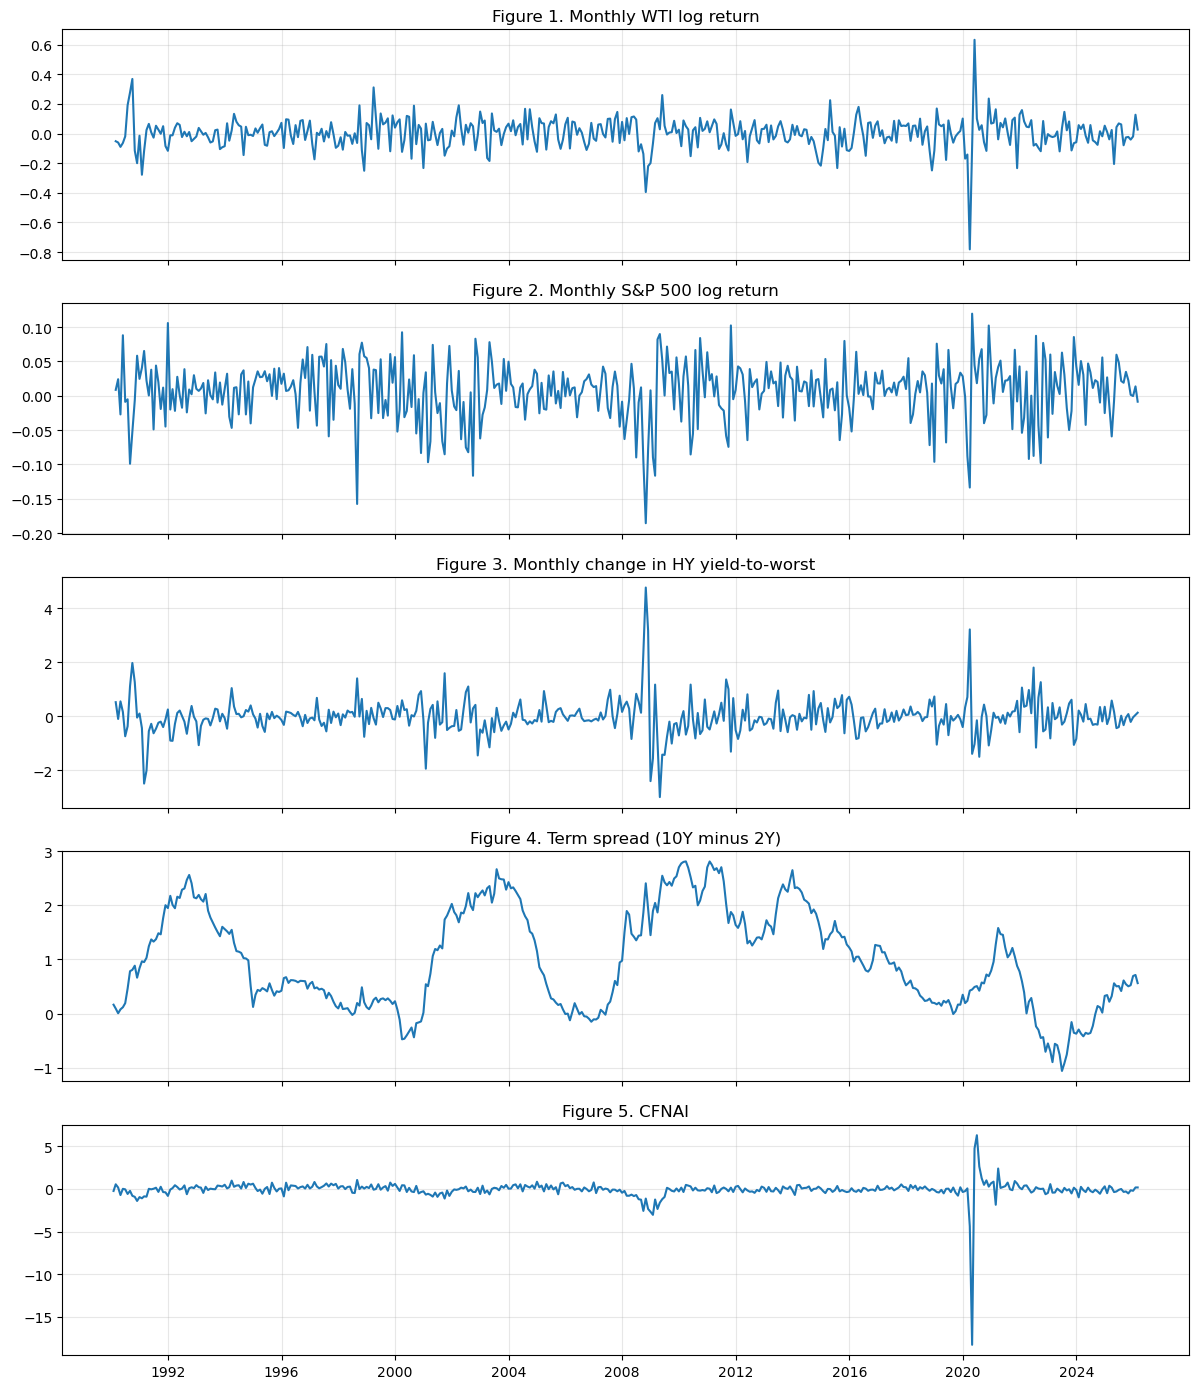

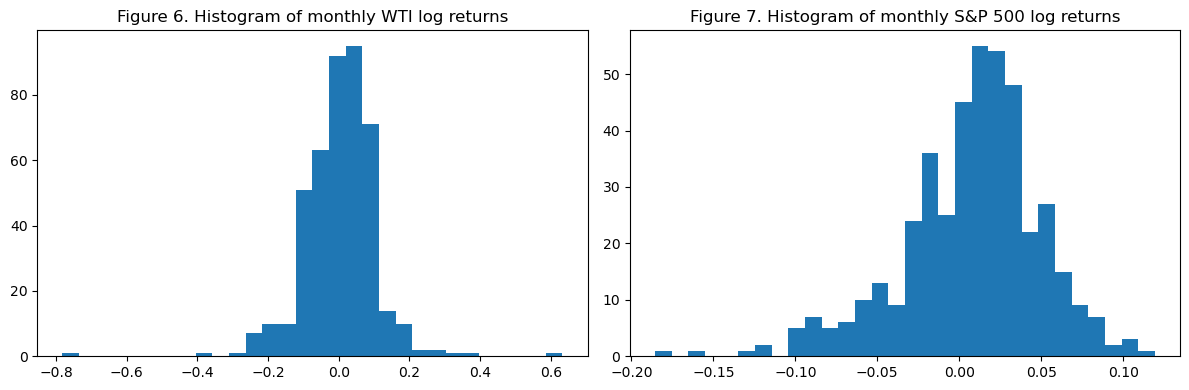

In [6]:
fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

plot_columns = [
    ("wti_return", "Figure 1. Monthly WTI log return"),
    ("sp500_return", "Figure 2. Monthly S&P 500 log return"),
    ("hy_change", "Figure 3. Monthly change in HY yield-to-worst"),
    ("term_spread", "Figure 4. Term spread (10Y minus 2Y)"),
    ("cfnai", "Figure 5. CFNAI"),
]

for ax, (column, title) in zip(axes, plot_columns):
    ax.plot(project_df["date"], project_df[column])
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(project_df["wti_return"].dropna(), bins=30)
axes[0].set_title("Figure 6. Histogram of monthly WTI log returns")
axes[1].hist(project_df["sp500_return"].dropna(), bins=30)
axes[1].set_title("Figure 7. Histogram of monthly S&P 500 log returns")
plt.tight_layout()
plt.show()

In [7]:
stationarity_columns = [
    "wti_return",
    "sp500_return",
    "hy_change",
    "term_spread",
    "gold_return",
    "cfnai",
    "ism_mfg",
]

print("Table 9. Augmented Dickey-Fuller tests")
adf_table = run_adf_table(project_df, stationarity_columns)
display(adf_table)

print("Phillips-Perron test is omitted here to keep the notebook limited to a simple standard package set.")

print("\nShort interpretation of the ADF results:")
for row in adf_table.itertuples(index=False):
    if pd.isna(row.p_value):
        print(f"{row.variable}: not enough data to run the test cleanly.")
    elif row.stationary_5pct:
        print(f"{row.variable}: appears stationary at the 5% level, so the transformation looks reasonable.")
    else:
        print(f"{row.variable}: does not clearly reject a unit root at the 5% level, so interpretation should stay cautious.")

Table 9. Augmented Dickey-Fuller tests


,variable,n_obs,adf_stat,p_value,stationary_5pct
0,wti_return,433,-12.2010,0.0000,True
1,sp500_return,433,-20.6803,0.0000,True
2,hy_change,433,-10.4457,0.0000,True
3,term_spread,434,-3.3442,0.0130,True
4,gold_return,433,-3.3210,0.0140,True
5,cfnai,434,-15.2059,0.0000,True
6,ism_mfg,434,-5.6506,0.0000,True


Phillips-Perron test is omitted here to keep the notebook limited to a simple standard package set.

Short interpretation of the ADF results:
wti_return: appears stationary at the 5% level, so the transformation looks reasonable.
sp500_return: appears stationary at the 5% level, so the transformation looks reasonable.
hy_change: appears stationary at the 5% level, so the transformation looks reasonable.
term_spread: appears stationary at the 5% level, so the transformation looks reasonable.
gold_return: appears stationary at the 5% level, so the transformation looks reasonable.
cfnai: appears stationary at the 5% level, so the transformation looks reasonable.
ism_mfg: appears stationary at the 5% level, so the transformation looks reasonable.


# 7. Oil shock decomposition

This is the key part of the project. We implement two complementary reduced-form approaches.

In the baseline specification, monthly WTI returns are regressed on CFNAI. The fitted value is interpreted as the demand-related component of oil movements, while the residual is interpreted as the non-demand-related component. This is not a structural identification strategy, but it provides a transparent way to separate oil moves that coincide with stronger macro activity from oil moves that do not.

As a robustness exercise, we repeat the same idea with ISM Manufacturing. We also build a simpler regime-based specification that interacts oil returns with expansion and contraction periods defined by the ISM threshold of 50.

In [8]:
decomposition_df, cfnai_decomp_model = decompose_oil_returns(
    project_df,
    oil_return_col="wti_return",
    activity_col="cfnai",
    prefix="baseline",
)

decomposition_df, ism_decomp_model = decompose_oil_returns(
    decomposition_df,
    oil_return_col="wti_return",
    activity_col="ism_mfg",
    prefix="ism",
)

decomposition_df = add_regime_variables(
    decomposition_df,
    oil_col="wti_return",
    ism_col="ism_mfg",
)

print("Table 10. Regression-based decomposition using CFNAI")
display(regression_results_table(cfnai_decomp_model))

print("Table 11. Regression-based decomposition using ISM Manufacturing")
display(regression_results_table(ism_decomp_model))

reconstruction_gap = (
    decomposition_df["wti_return"]
    - decomposition_df["baseline_oil_demand_component"]
    - decomposition_df["baseline_oil_supply_component"]
).dropna()
print("Maximum absolute reconstruction gap:", reconstruction_gap.abs().max())

print("\nReminder: both components are reduced-form objects, not structural shocks.")

Table 10. Regression-based decomposition using CFNAI


,coef,std_err,t_stat,p_value
const,0.0038,0.0049,0.7809,0.4353
cfnai,0.0184,0.0044,4.1777,0.0000


Table 11. Regression-based decomposition using ISM Manufacturing


,coef,std_err,t_stat,p_value
const,-0.1488,0.0534,-2.7853,0.0056
ism_mfg,0.0029,0.0010,2.8445,0.0047


Maximum absolute reconstruction gap: 0.0

Reminder: both components are reduced-form objects, not structural shocks.


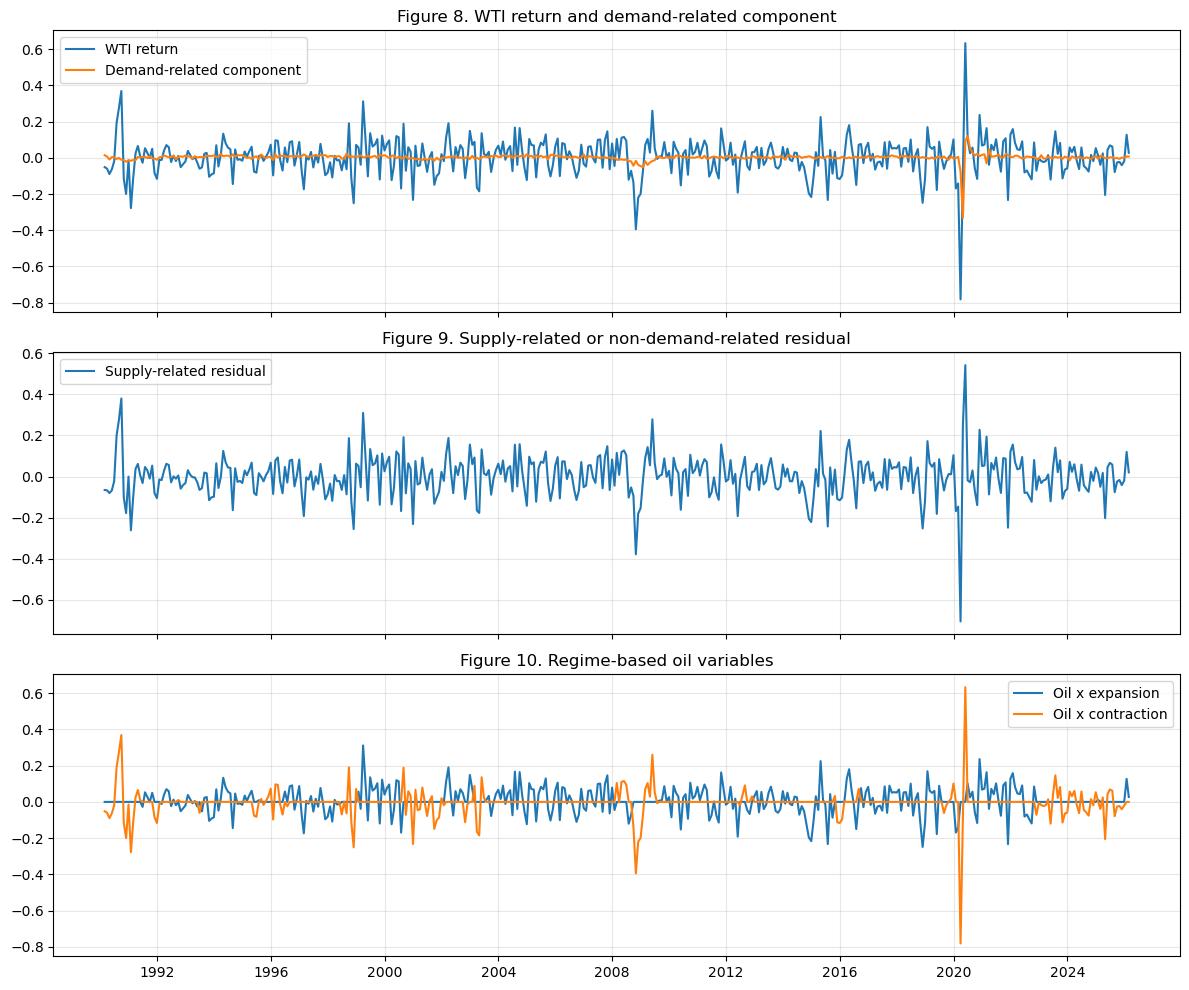

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(decomposition_df["date"], decomposition_df["wti_return"], label="WTI return")
axes[0].plot(
    decomposition_df["date"],
    decomposition_df["baseline_oil_demand_component"],
    label="Demand-related component",
)
axes[0].set_title("Figure 8. WTI return and demand-related component")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    decomposition_df["date"],
    decomposition_df["baseline_oil_supply_component"],
    label="Supply-related residual",
)
axes[1].set_title("Figure 9. Supply-related or non-demand-related residual")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(decomposition_df["date"], decomposition_df["oil_expansion"], label="Oil x expansion")
axes[2].plot(decomposition_df["date"], decomposition_df["oil_contraction"], label="Oil x contraction")
axes[2].set_title("Figure 10. Regime-based oil variables")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 8. Predictive regressions

We now estimate one-month-ahead predictive regressions. The key timing choice is important: predictors are measured at time *t* and the dependent variable is shifted to *t+1*, so the regressions avoid look-ahead bias.

The baseline specification uses the demand-related and supply-related oil components, together with a small control set: the current value of the dependent variable, the term spread, gold return, and realized S&P 500 volatility. We estimate the regressions with heteroskedasticity-robust standard errors.

In [10]:
def interpret_pair(model, variables, labels):
    for variable, label in zip(variables, labels):
        coef = model.params.get(variable, np.nan)
        p_value = model.pvalues.get(variable, np.nan)
        sign = "positive" if coef > 0 else "negative"
        significance = "statistically significant" if p_value < 0.05 else "not statistically significant"
        print(f"{label}: coefficient is {sign} ({coef:.4f}) and {significance} at the 5% level (p-value = {p_value:.4f}).")

target_map = {
    "sp500_return": "S&P 500 next-month return",
    "hy_change": "High-yield next-month change",
}

decomposition_models = {}
regime_models = {}

for target, label in target_map.items():
    decomposition_predictors = [
        "baseline_oil_demand_component",
        "baseline_oil_supply_component",
        target,
        "term_spread",
        "gold_return",
        "sp500_realized_vol",
    ]

    decomp_model, decomp_sample = fit_predictive_regression(
        decomposition_df,
        dependent_col=target,
        predictor_cols=decomposition_predictors,
        horizon=1,
        cov_type="HC1",
    )
    decomposition_models[target] = (decomp_model, decomp_sample)

    print(f"Table for {label}: decomposition model")
    print("Regression sample size:", len(decomp_sample))
    display(regression_results_table(decomp_model))
    interpret_pair(
        decomp_model,
        ["baseline_oil_demand_component", "baseline_oil_supply_component"],
        ["Demand-related oil effect", "Supply-related oil effect"],
    )
    print("")

    regime_predictors = [
        "oil_expansion",
        "oil_contraction",
        target,
        "term_spread",
        "gold_return",
        "sp500_realized_vol",
    ]

    regime_model, regime_sample = fit_predictive_regression(
        decomposition_df,
        dependent_col=target,
        predictor_cols=regime_predictors,
        horizon=1,
        cov_type="HC1",
    )
    regime_models[target] = (regime_model, regime_sample)

    print(f"Table for {label}: regime-based model")
    print("Regression sample size:", len(regime_sample))
    display(regression_results_table(regime_model))
    interpret_pair(
        regime_model,
        ["oil_expansion", "oil_contraction"],
        ["Oil effect during ISM expansion", "Oil effect during ISM contraction"],
    )
    print("-" * 100)

Table for S&P 500 next-month return: decomposition model
Regression sample size: 432


,coef,std_err,t_stat,p_value
const,0.0110,0.0062,1.7674,0.0772
baseline_oil_demand_component,0.0090,0.1357,0.0662,0.9472
baseline_oil_supply_component,-0.0377,0.0254,-1.4813,0.1385
sp500_return_current,0.0067,0.0638,0.1043,0.9169
term_spread,-0.0012,0.0022,-0.5559,0.5783
gold_return,-0.0420,0.0530,-0.7923,0.4282
sp500_realized_vol,-0.2694,0.6068,-0.4440,0.6570


Demand-related oil effect: coefficient is positive (0.0090) and not statistically significant at the 5% level (p-value = 0.9472).
Supply-related oil effect: coefficient is negative (-0.0377) and not statistically significant at the 5% level (p-value = 0.1385).

Table for S&P 500 next-month return: regime-based model
Regression sample size: 432


,coef,std_err,t_stat,p_value
const,0.0131,0.0061,2.1577,0.0309
oil_expansion,0.0020,0.0323,0.0632,0.9496
oil_contraction,-0.0732,0.0389,-1.8820,0.0598
sp500_return_current,-0.0084,0.0642,-0.1310,0.8958
term_spread,-0.0013,0.0022,-0.6022,0.5470
gold_return,-0.0440,0.0537,-0.8200,0.4122
sp500_realized_vol,-0.5040,0.6113,-0.8244,0.4097


Oil effect during ISM expansion: coefficient is positive (0.0020) and not statistically significant at the 5% level (p-value = 0.9496).
Oil effect during ISM contraction: coefficient is negative (-0.0732) and not statistically significant at the 5% level (p-value = 0.0598).
----------------------------------------------------------------------------------------------------
Table for High-yield next-month change: decomposition model
Regression sample size: 432


,coef,std_err,t_stat,p_value
const,0.1336,0.1060,1.2613,0.2072
baseline_oil_demand_component,0.9152,1.7373,0.5268,0.5983
baseline_oil_supply_component,0.8835,0.3773,2.3418,0.0192
hy_change_current,0.3221,0.0986,3.2682,0.0011
term_spread,-0.0420,0.0332,-1.2655,0.2057
gold_return,-0.0612,1.0029,-0.0610,0.9514
sp500_realized_vol,-11.5419,11.1668,-1.0336,0.3013


Demand-related oil effect: coefficient is positive (0.9152) and not statistically significant at the 5% level (p-value = 0.5983).
Supply-related oil effect: coefficient is positive (0.8835) and statistically significant at the 5% level (p-value = 0.0192).

Table for High-yield next-month change: regime-based model
Regression sample size: 432


,coef,std_err,t_stat,p_value
const,0.1195,0.1103,1.0839,0.2784
oil_expansion,0.4011,0.4288,0.9354,0.3496
oil_contraction,1.3498,0.6281,2.1489,0.0316
hy_change_current,0.3186,0.0982,3.2432,0.0012
term_spread,-0.0416,0.0332,-1.2553,0.2094
gold_return,-0.0594,1.0143,-0.0586,0.9533
sp500_realized_vol,-9.5183,11.5346,-0.8252,0.4093


Oil effect during ISM expansion: coefficient is positive (0.4011) and not statistically significant at the 5% level (p-value = 0.3496).
Oil effect during ISM contraction: coefficient is positive (1.3498) and statistically significant at the 5% level (p-value = 0.0316).
----------------------------------------------------------------------------------------------------


# 9. Granger causality tests

The Granger causality exercise is kept intentionally narrow. Instead of testing many combinations mechanically, we focus on the four relationships most directly linked to the project question: whether the two oil components help predict future equity returns and future changes in high-yield spreads.

In [11]:
granger_specs = [
    ("baseline_oil_demand_component", "sp500_return"),
    ("baseline_oil_supply_component", "sp500_return"),
    ("baseline_oil_demand_component", "hy_change"),
    ("baseline_oil_supply_component", "hy_change"),
]

granger_tables = []
for cause, effect in granger_specs:
    table = granger_pvalue_table(decomposition_df, cause, effect, max_lag=3)
    granger_tables.append(table)

granger_summary = pd.concat(granger_tables, ignore_index=True)
print("Table 12. Granger causality p-values")
display(granger_summary)

print("\nShort reading of the Granger results:")
for (cause, effect), group in granger_summary.groupby(["cause", "effect"]):
    best_p = group["p_value"].min()
    if best_p < 0.05:
        print(f"{cause} shows some predictive content for {effect} over at least one lag in the 1 to 3 range.")
    else:
        print(f"{cause} does not show strong Granger evidence for {effect} over lags 1 to 3.")

Table 12. Granger causality p-values


,cause,effect,lag,p_value
0,baseline_oil_demand_component,sp500_return,1,0.6812
1,baseline_oil_demand_component,sp500_return,2,0.6780
2,baseline_oil_demand_component,sp500_return,3,0.9375
3,baseline_oil_supply_component,sp500_return,1,0.0652
4,baseline_oil_supply_component,sp500_return,2,0.0842
5,baseline_oil_supply_component,sp500_return,3,0.1690
6,baseline_oil_demand_component,hy_change,1,0.1577
7,baseline_oil_demand_component,hy_change,2,0.6904
8,baseline_oil_demand_component,hy_change,3,0.0050
9,baseline_oil_supply_component,hy_change,1,0.0013



Short reading of the Granger results:
baseline_oil_demand_component shows some predictive content for hy_change over at least one lag in the 1 to 3 range.
baseline_oil_demand_component does not show strong Granger evidence for sp500_return over lags 1 to 3.
baseline_oil_supply_component shows some predictive content for hy_change over at least one lag in the 1 to 3 range.
baseline_oil_supply_component does not show strong Granger evidence for sp500_return over lags 1 to 3.


# 10. VAR and impulse responses

As an extension, we estimate a reduced-form monthly VAR. The goal is not structural identification. Instead, the VAR gives a compact way to inspect dynamic comovement and to see whether the impulse responses tell a story broadly consistent with the predictive regressions.

In [12]:
var_columns = [
    "wti_return",
    "sp500_return",
    "term_spread",
    "hy_change",
    "gold_return",
    "ism_mfg",
]

var_df = decomposition_df[["date"] + var_columns].dropna().copy()
var_df = var_df.set_index("date")

print("VAR sample shape:", var_df.shape)
print("VAR sample period:", var_df.index.min(), "to", var_df.index.max())

var_model = VAR(var_df)
lag_selection = var_model.select_order(maxlags=6)

lag_choice_table = pd.DataFrame([lag_selection.selected_orders], index=["selected_lag"])
print("Table 13. VAR lag choice suggested by information criteria")
display(lag_choice_table)

chosen_lag = lag_selection.selected_orders["bic"]
if chosen_lag == 0:
    chosen_lag = max(1, lag_selection.selected_orders["aic"])

print("Chosen lag for the baseline VAR:", chosen_lag)
var_results = var_model.fit(chosen_lag)

print("Table 14. Reduced-form VAR coefficients")
display(var_results.params.round(4))

print("Table 15. Reduced-form VAR p-values")
display(var_results.pvalues.round(4))

VAR sample shape: (433, 6)
VAR sample period: 1990-02-28 00:00:00 to 2026-02-28 00:00:00
Table 13. VAR lag choice suggested by information criteria


,aic,bic,hqic,fpe
selected_lag,1,1,1,1


Chosen lag for the baseline VAR: 1
Table 14. Reduced-form VAR coefficients


,wti_return,sp500_return,term_spread,hy_change,gold_return,ism_mfg
const,-0.0810,-0.0044,0.3584,-0.8421,0.0270,4.1665
L1.wti_return,0.0900,-0.0355,0.0966,0.9325,-0.0002,3.6289
L1.sp500_return,-0.2226,-0.0044,-0.5049,-2.1723,-0.1281,5.5469
L1.term_spread,-0.0049,-0.0018,0.9831,-0.0729,-0.0005,0.2427
L1.hy_change,-0.0427,-0.0024,-0.0606,0.1819,-0.0071,-0.4718
L1.gold_return,-0.0884,-0.0485,-0.1755,-0.2906,-0.0703,-2.3789
L1.ism_mfg,0.0017,0.0003,-0.0065,0.0174,-0.0004,0.9148


Table 15. Reduced-form VAR p-values


,wti_return,sp500_return,term_spread,hy_change,gold_return,ism_mfg
const,0.1310,0.8452,0.0000,0.0096,0.2447,0.0000
L1.wti_return,0.0708,0.0903,0.2047,0.0020,0.9925,0.0000
L1.sp500_return,0.1331,0.9436,0.0260,0.0156,0.0460,0.0213
L1.term_spread,0.3695,0.4502,0.0000,0.0291,0.8198,0.0067
L1.hy_change,0.0000,0.5719,0.0001,0.0029,0.1020,0.0039
L1.gold_return,0.4363,0.3105,0.3125,0.6729,0.1525,0.1973
L1.ism_mfg,0.0985,0.5531,0.0000,0.0056,0.4077,0.0000


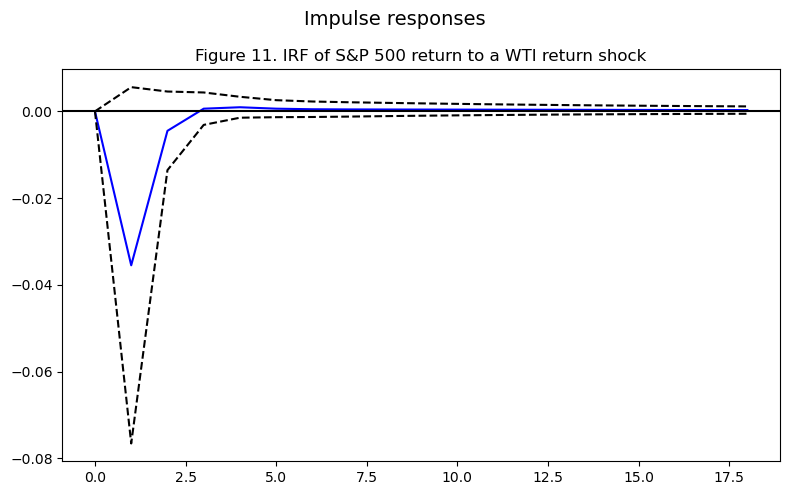

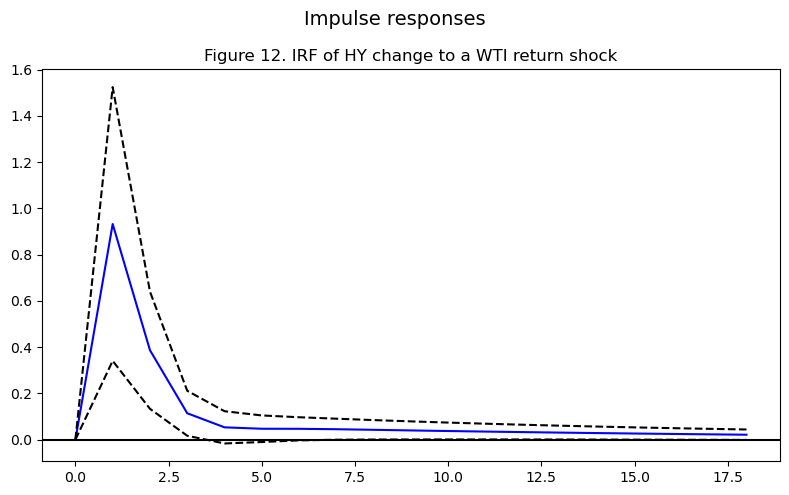

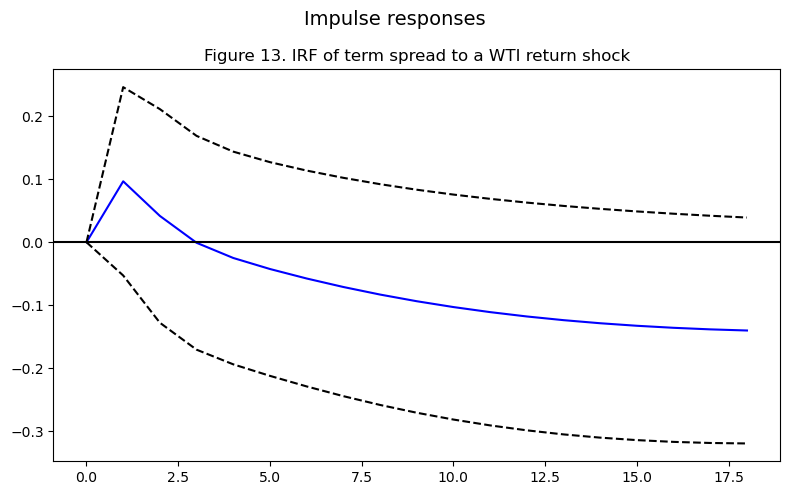

Table 16. Simple FEVD summary at the 12-month horizon


,variable,share_of_12_month_fevd_explained_by_wti_shock
0,sp500_return,0.0529
1,hy_change,0.0835
2,term_spread,0.0062


In [13]:
irf_horizon = 18
irf = var_results.irf(irf_horizon)

fig1 = irf.plot(impulse="wti_return", response="sp500_return")
fig1.set_size_inches(8, 5)
fig1.axes[0].set_title("Figure 11. IRF of S&P 500 return to a WTI return shock")
plt.tight_layout()
plt.show()

fig2 = irf.plot(impulse="wti_return", response="hy_change")
fig2.set_size_inches(8, 5)
fig2.axes[0].set_title("Figure 12. IRF of HY change to a WTI return shock")
plt.tight_layout()
plt.show()

fig3 = irf.plot(impulse="wti_return", response="term_spread")
fig3.set_size_inches(8, 5)
fig3.axes[0].set_title("Figure 13. IRF of term spread to a WTI return shock")
plt.tight_layout()
plt.show()

try:
    fevd = var_results.fevd(12)
    shock_index = list(var_df.columns).index("wti_return")
    fevd_rows = []
    for variable in ["sp500_return", "hy_change", "term_spread"]:
        variable_index = list(var_df.columns).index(variable)
        share = fevd.decomp[variable_index, 11, shock_index]
        fevd_rows.append(
            {
                "variable": variable,
                "share_of_12_month_fevd_explained_by_wti_shock": share,
            }
        )

    print("Table 16. Simple FEVD summary at the 12-month horizon")
    display(pd.DataFrame(fevd_rows).round(4))
except Exception as error:
    print("FEVD is omitted because the simple summary extraction failed:", error)

# 11. Out-of-sample exercise

We now compare three simple forecasting approaches in an expanding-window setting:

1. A historical mean benchmark.
2. A model with the raw oil return.
3. A model with the demand-related and supply-related oil components.

This part is intentionally modest. The goal is simply to see whether the decomposition adds predictive value relative to a benchmark that treats oil as a single undifferentiated return series.

Table for S&P 500 next-month return: out-of-sample forecasting performance


,model,rmse,mae
0,benchmark,0.0404,0.0308
1,raw_oil_model,0.0417,0.0312
2,decomposition_model,0.0436,0.0318


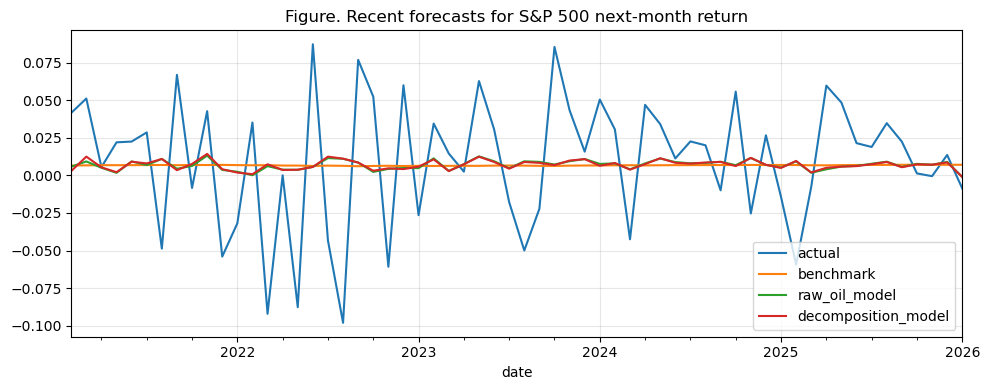

Table for High-yield next-month change: out-of-sample forecasting performance


,model,rmse,mae
0,benchmark,0.5526,0.3816
1,raw_oil_model,0.5814,0.4027
2,decomposition_model,0.5845,0.4047


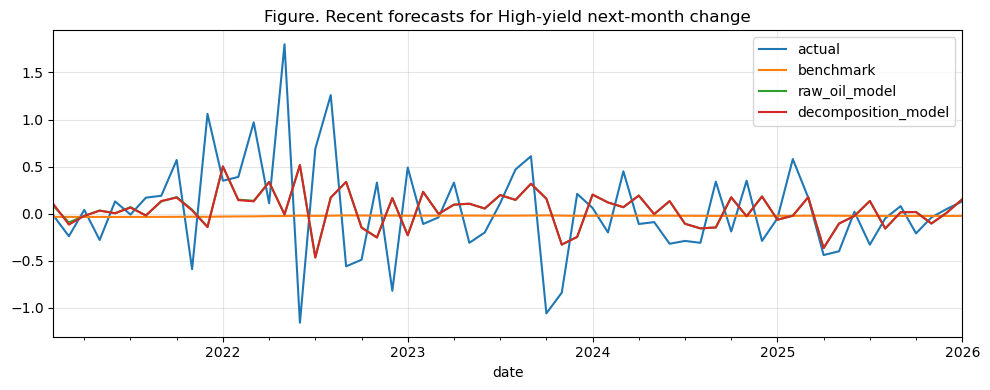

In [14]:
forecast_targets = {
    "sp500_return": "S&P 500 next-month return",
    "hy_change": "High-yield next-month change",
}

forecast_metrics = {}

for target, label in forecast_targets.items():
    forecast_df, metrics_df = rolling_forecast_comparison(
        decomposition_df,
        target_col=target,
        raw_oil_col="wti_return",
        demand_col="baseline_oil_demand_component",
        supply_col="baseline_oil_supply_component",
        controls=["term_spread", "gold_return", "sp500_realized_vol"],
        start_share=0.6,
    )

    forecast_metrics[target] = (forecast_df, metrics_df)
    print(f"Table for {label}: out-of-sample forecasting performance")
    display(metrics_df)

    if not forecast_df.empty:
        fig, ax = plt.subplots(figsize=(10, 4))
        plot_df = forecast_df.set_index("date")
        plot_df[["actual", "benchmark", "raw_oil_model", "decomposition_model"]].tail(60).plot(ax=ax)
        ax.set_title(f"Figure. Recent forecasts for {label}")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

# 12. Robustness checks

We keep the robustness section short and focused. The aim is not to multiply specifications, but to check whether the core message survives a few sensible variations:

- replacing WTI with Brent,
- using ISM rather than CFNAI in the decomposition,
- changing the equity market from the S&P 500 to MSCI Emerging Markets,
- and splitting the sample around the 2008 financial crisis.

In [15]:
robustness_rows = []

brent_df, brent_decomp_model = decompose_oil_returns(
    decomposition_df,
    oil_return_col="brent_return",
    activity_col="cfnai",
    prefix="brent",
)
brent_predictive_model, brent_sample = fit_predictive_regression(
    brent_df,
    dependent_col="sp500_return",
    predictor_cols=[
        "brent_oil_demand_component",
        "brent_oil_supply_component",
        "sp500_return",
        "term_spread",
        "gold_return",
        "sp500_realized_vol",
    ],
    horizon=1,
    cov_type="HC1",
)
robustness_rows.append(
    {
        "check": "Brent instead of WTI",
        "sample_size": len(brent_sample),
        "component_1": brent_predictive_model.params.get("brent_oil_demand_component", np.nan),
        "component_1_pvalue": brent_predictive_model.pvalues.get("brent_oil_demand_component", np.nan),
        "component_2": brent_predictive_model.params.get("brent_oil_supply_component", np.nan),
        "component_2_pvalue": brent_predictive_model.pvalues.get("brent_oil_supply_component", np.nan),
    }
)

ism_predictive_model, ism_sample = fit_predictive_regression(
    decomposition_df,
    dependent_col="sp500_return",
    predictor_cols=[
        "ism_oil_demand_component",
        "ism_oil_supply_component",
        "sp500_return",
        "term_spread",
        "gold_return",
        "sp500_realized_vol",
    ],
    horizon=1,
    cov_type="HC1",
)
robustness_rows.append(
    {
        "check": "ISM decomposition instead of CFNAI",
        "sample_size": len(ism_sample),
        "component_1": ism_predictive_model.params.get("ism_oil_demand_component", np.nan),
        "component_1_pvalue": ism_predictive_model.pvalues.get("ism_oil_demand_component", np.nan),
        "component_2": ism_predictive_model.params.get("ism_oil_supply_component", np.nan),
        "component_2_pvalue": ism_predictive_model.pvalues.get("ism_oil_supply_component", np.nan),
    }
)

em_predictive_model, em_sample = fit_predictive_regression(
    decomposition_df,
    dependent_col="msci_em_return",
    predictor_cols=[
        "baseline_oil_demand_component",
        "baseline_oil_supply_component",
        "msci_em_return",
        "term_spread",
        "gold_return",
        "sp500_realized_vol",
    ],
    horizon=1,
    cov_type="HC1",
)
robustness_rows.append(
    {
        "check": "MSCI EM instead of S&P 500",
        "sample_size": len(em_sample),
        "component_1": em_predictive_model.params.get("baseline_oil_demand_component", np.nan),
        "component_1_pvalue": em_predictive_model.pvalues.get("baseline_oil_demand_component", np.nan),
        "component_2": em_predictive_model.params.get("baseline_oil_supply_component", np.nan),
        "component_2_pvalue": em_predictive_model.pvalues.get("baseline_oil_supply_component", np.nan),
    }
)

pre_2008, post_2008 = split_sample(decomposition_df, pd.Timestamp("2008-09-30"))

if len(pre_2008) > 60:
    pre_model, pre_sample = fit_predictive_regression(
        pre_2008,
        dependent_col="sp500_return",
        predictor_cols=[
            "baseline_oil_demand_component",
            "baseline_oil_supply_component",
            "sp500_return",
            "term_spread",
            "gold_return",
            "sp500_realized_vol",
        ],
        horizon=1,
        cov_type="HC1",
    )
    robustness_rows.append(
        {
            "check": "Pre-2008 sample",
            "sample_size": len(pre_sample),
            "component_1": pre_model.params.get("baseline_oil_demand_component", np.nan),
            "component_1_pvalue": pre_model.pvalues.get("baseline_oil_demand_component", np.nan),
            "component_2": pre_model.params.get("baseline_oil_supply_component", np.nan),
            "component_2_pvalue": pre_model.pvalues.get("baseline_oil_supply_component", np.nan),
        }
    )

if len(post_2008) > 60:
    post_model, post_sample = fit_predictive_regression(
        post_2008,
        dependent_col="sp500_return",
        predictor_cols=[
            "baseline_oil_demand_component",
            "baseline_oil_supply_component",
            "sp500_return",
            "term_spread",
            "gold_return",
            "sp500_realized_vol",
        ],
        horizon=1,
        cov_type="HC1",
    )
    robustness_rows.append(
        {
            "check": "Post-2008 sample",
            "sample_size": len(post_sample),
            "component_1": post_model.params.get("baseline_oil_demand_component", np.nan),
            "component_1_pvalue": post_model.pvalues.get("baseline_oil_demand_component", np.nan),
            "component_2": post_model.params.get("baseline_oil_supply_component", np.nan),
            "component_2_pvalue": post_model.pvalues.get("baseline_oil_supply_component", np.nan),
        }
    )

print("Table 17. Selected robustness checks")
display(pd.DataFrame(robustness_rows).round(4))

Table 17. Selected robustness checks


,check,sample_size,component_1,component_1_pvalue,component_2,component_2_pvalue
0,Brent instead of WTI,432,0.0108,0.9587,-0.0431,0.1258
1,ISM decomposition instead of CFNAI,432,-0.0021,0.9907,-0.0366,0.1491
2,MSCI EM instead of S&P 500,432,0.1636,0.2628,-0.0573,0.0803
3,Pre-2008 sample,222,0.2427,0.4790,-0.1063,0.0008
4,Post-2008 sample,209,-0.0198,0.8579,0.0135,0.7471


# 13. Main conclusions

The goal of the project is not to claim a fully structural causal interpretation. Instead, the contribution of the notebook is to show, in a transparent monthly framework, whether it is empirically useful to distinguish oil price increases that coincide with stronger activity from oil price increases that do not.

The final code block below turns the main outputs into a short project-style conclusion. This keeps the interpretation tied to the actual regression and forecasting results obtained in the notebook.

In [16]:
sp500_model = decomposition_models["sp500_return"][0]
hy_model = decomposition_models["hy_change"][0]

sp500_forecast_metrics = forecast_metrics["sp500_return"][1].set_index("model")
hy_forecast_metrics = forecast_metrics["hy_change"][1].set_index("model")

print("Project conclusion summary")
print("")
print("1. The decomposition remains reduced-form throughout the notebook.")
print("   The fitted part is interpreted as demand-related and the residual as supply-related or non-demand-related.")
print("")
print("2. Predictive regressions for next-month S&P 500 returns:")
for line in interpret_two_component_model(
    sp500_model,
    "baseline_oil_demand_component",
    "baseline_oil_supply_component",
):
    print("   " + line)
print("")
print("3. Predictive regressions for next-month HY changes:")
for line in interpret_two_component_model(
    hy_model,
    "baseline_oil_demand_component",
    "baseline_oil_supply_component",
):
    print("   " + line)
print("")
print("4. Out-of-sample forecasting for S&P 500 returns:")
print(sp500_forecast_metrics)
print("")
print("5. Out-of-sample forecasting for HY changes:")
print(hy_forecast_metrics)
print("")
print("These results should be read as transparent empirical evidence, not as full causal identification.")

Project conclusion summary

1. The decomposition remains reduced-form throughout the notebook.
   The fitted part is interpreted as demand-related and the residual as supply-related or non-demand-related.

2. Predictive regressions for next-month S&P 500 returns:
   Demand-related oil component: coefficient is positive (0.0090) and not statistically significant at the 5% level (p-value = 0.9472).
   Supply-related oil component: coefficient is negative (-0.0377) and not statistically significant at the 5% level (p-value = 0.1385).

3. Predictive regressions for next-month HY changes:
   Demand-related oil component: coefficient is positive (0.9152) and not statistically significant at the 5% level (p-value = 0.5983).
   Supply-related oil component: coefficient is positive (0.8835) and statistically significant at the 5% level (p-value = 0.0192).

4. Out-of-sample forecasting for S&P 500 returns:
                      rmse    mae
model                            
benchmark           0.